# 1. Загрузка и Интеграция Данных (Data Ingestion & Integration)

В данном блоке производится первичный сбор сырых данных:
*   Установка путей через `os.getcwd()` и `os.path.join` для обеспечения переносимости кода.
*   Загрузка реляционных таблиц (`purchases`, `personal_data`, `personal_data_coeffs`) из локальной базы данных SQLite (`shop_database.db`).
*   Проверка целевых групп для предстоящего AB тестирования(`df_ab_pos`, `df_ab_neg`) на отсутствие пересечений, чтобы исключить утечку данных (data leakage).
*   Конвертация первичных ключей (`id`) в строковый формат для корректного и безопасного слияния (merge) таблиц в дальнейшем.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sqlalchemy import create_engine
import re
from deep_translator import GoogleTranslator
import webcolors
import json
from skimage import color
import spacy

from sklearn.neighbors import KNeighborsClassifier

In [2]:
BASE_DIR = os.getcwd()
DATA_FOLDER = 'data'

In [3]:
FILE_NAME_IDS_POS = 'ids_first_company_positive.txt'
FILE_NAME_IDS_NEG = 'ids_first_company_negative.txt'
FULL_PATH_POS = os.path.join(BASE_DIR, DATA_FOLDER, FILE_NAME_IDS_POS)
FULL_PATH_NEG = os.path.join(BASE_DIR, DATA_FOLDER, FILE_NAME_IDS_NEG)

FILE_NAME_IDS_POS_CSV = 'df_ab_pos.csv'
FILE_NAME_IDS_NEG_CSV = 'df_ab_neg.csv'
FULL_PATH_POS_CSV = os.path.join(BASE_DIR, DATA_FOLDER, FILE_NAME_IDS_POS_CSV)
FULL_PATH_NEG_CSV = os.path.join(BASE_DIR, DATA_FOLDER, FILE_NAME_IDS_NEG_CSV)

dfs_ab = {
    'df_pos': [None, FULL_PATH_POS],
    'df_neg': [None, FULL_PATH_NEG]
}

for ls in dfs_ab:
    with open(dfs_ab[ls][1], 'r') as f:
        ids = f.read()
    text = re.sub(r'\n', '', ids)
    dfs_ab[ls][0] = pd.DataFrame(re.sub(r'\D+', ' ', text).split(), columns=['id'])

df_ab_pos = dfs_ab['df_pos'][0]     #.reset_index(drop=True)
df_ab_neg = dfs_ab['df_neg'][0]     #.reset_index(drop=True)

try:
    df_ab_pos.astype(int), df_ab_neg.astype(int)
    df_ab_pos.to_csv(FULL_PATH_POS_CSV, index=False)
    df_ab_neg.to_csv(FULL_PATH_NEG_CSV, index=False)
    df_ab_pos.info()
    print('\n')
    df_ab_neg.info()
except:
    print('Данные нормализованы некорректно')



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      5000 non-null   object
dtypes: object(1)
memory usage: 39.2+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      5000 non-null   object
dtypes: object(1)
memory usage: 39.2+ KB


In [4]:
client_set = set(df_ab_pos['id'].unique()) & set(df_ab_neg['id'].unique())
print(f'Проверка на отсутствие пересечений по клиентам у двух тестируемых групп:\n\t-количество общих клиентов {len(client_set)}')

Проверка на отсутствие пересечений по клиентам у двух тестируемых групп:
	-количество общих клиентов 0


In [5]:
file_name = 'shop_database.db'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

engine = create_engine(f'sqlite:///{full_path}')
#pd.read_sql('SHOW TABLES', engine)
pd.read_sql('SELECT name FROM sqlite_master WHERE type="table"', engine)

,name
0,purchases
1,personal_data_coeffs
2,personal_data


In [6]:
df_coeffs = pd.read_sql('SELECT * FROM personal_data_coeffs', engine)
df_coeffs['id'] = df_coeffs['id'].astype('str')

file_name = 'df_coeffs.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_coeffs.to_csv(full_path, index=False)
df_coeffs

,id,lbt_coef,ac_coef,sm_coef,personal_coef
0,0,5.078678,-0.307147,0.959027,0.5072
1,3,7.764766,-0.030225,0.794720,0.4304
2,4,4.569378,0.063693,0.820892,0.5072
3,6,8.150379,0.075200,0.836140,0.4304
4,7,5.188231,-0.000134,0.944113,0.5072
...,...,...,...,...,...
104984,177998,4.740988,0.364797,1.165888,0.5072
104985,177999,7.303172,0.431899,1.317100,0.4304
104986,178001,5.241579,0.430391,0.356182,0.2576
104987,178002,7.542436,-0.290921,0.800338,0.4304


In [7]:
df_clients = pd.read_sql('SELECT * FROM personal_data', engine)
df_clients

,id,gender,age,education,city,country
0,0,0,36,среднее,1201,32
1,4,0,35,среднее,1134,32
2,6,1,52,среднее,1188,32
3,7,0,37,среднее,1198,32
4,9,0,48,среднее,1134,32
...,...,...,...,...,...,...
89236,177997,0,28,среднее,1134,32
89237,177998,0,32,среднее,1201,32
89238,177999,1,34,среднее,1163,32
89239,178001,1,5,среднее,1208,32


In [8]:
file_name = 'personal_data.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_lost_clients = pd.read_csv(full_path)
df_lost_clients

,id,age,education,city,country
0,101492,32,среднее,1188,32
1,42690,20,высшее,1134,32
2,113001,27,среднее,1187,32
3,163654,49,высшее,1160,32
4,69523,44,среднее,1137,32
...,...,...,...,...,...
15743,135183,44,среднее,1134,32
15744,125993,46,среднее,1134,32
15745,167019,71,среднее,1134,32
15746,116355,32,среднее,1188,32


In [9]:
df_clients.info()
df_lost_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89241 entries, 0 to 89240
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         89241 non-null  int64 
 1   gender     89241 non-null  int64 
 2   age        89241 non-null  int64 
 3   education  89241 non-null  object
 4   city       89241 non-null  int64 
 5   country    89241 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 4.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15748 entries, 0 to 15747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         15748 non-null  int64 
 1   age        15748 non-null  int64 
 2   education  15748 non-null  object
 3   city       15748 non-null  int64 
 4   country    15748 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 615.3+ KB


In [10]:
dfs = [df_clients, df_lost_clients]
cols = ['id', 'city', 'country']
for df in dfs:
    df[cols] = df[cols].astype('str')

In [11]:
df_clients.info()
df_lost_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89241 entries, 0 to 89240
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         89241 non-null  object
 1   gender     89241 non-null  int64 
 2   age        89241 non-null  int64 
 3   education  89241 non-null  object
 4   city       89241 non-null  object
 5   country    89241 non-null  object
dtypes: int64(2), object(4)
memory usage: 4.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15748 entries, 0 to 15747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         15748 non-null  object
 1   age        15748 non-null  int64 
 2   education  15748 non-null  object
 3   city       15748 non-null  object
 4   country    15748 non-null  object
dtypes: int64(1), object(4)
memory usage: 615.3+ KB


In [12]:
dfs = {}
dfs['df_clients'] = df_clients
dfs['df_lost_clients'] = df_lost_clients

print(f'Проверка ID на пересечение в двух базах:\n{len(set(df_lost_clients['id'].unique()) & set(df_clients['id'].unique()))} совпадений')

print(f'\nПроверка клиентов на уникальность:')
for df in dfs.keys():
    print(f'\t для {df}: {dfs[df]['id'].duplicated().sum()} повторений')

Проверка ID на пересечение в двух базах:
0 совпадений

Проверка клиентов на уникальность:
	 для df_clients: 0 повторений
	 для df_lost_clients: 0 повторений


In [13]:
df_lost_clients['gender'] = np.nan
df_lost_clients = df_lost_clients[df_clients.columns]
df_clients = pd.concat([df_clients, df_lost_clients], ignore_index=True)

In [14]:
file_name = 'df_clients.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_clients.to_csv(full_path, index=False)

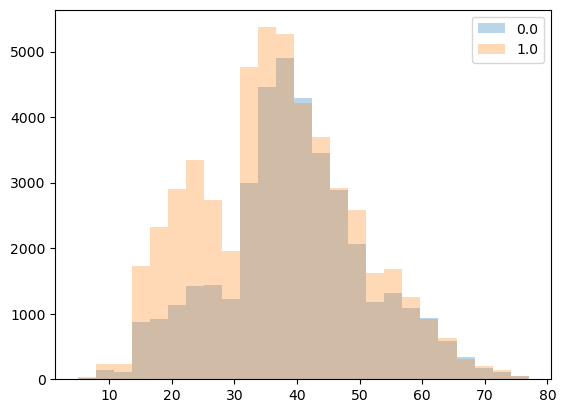

In [15]:
for gen in df_clients['gender'].unique()[:-1]:
    mask = df_clients['gender'] == gen
    plt.hist(df_clients['age'][mask], bins=25, label=gen, alpha=0.3)

plt.legend()
plt.show()

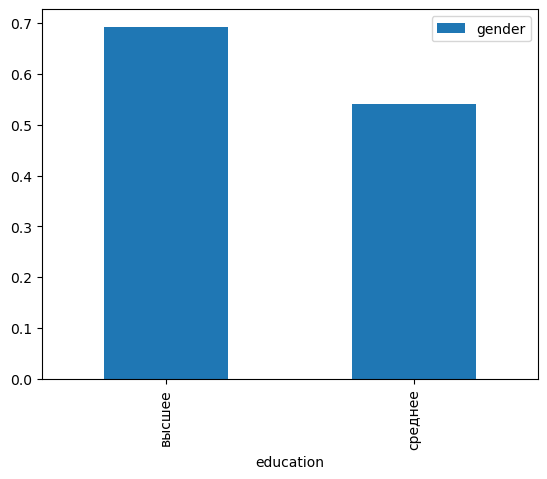

In [16]:
df_clients.groupby(['education']).agg({'gender':'mean'}).plot(kind='bar')
plt.show()

In [17]:
df_purchases = pd.read_sql('SELECT * FROM purchases', engine, dtype={'id':str})
df_purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786260 entries, 0 to 786259
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           786260 non-null  object 
 1   product      786260 non-null  object 
 2   colour       666736 non-null  object 
 3   cost         786260 non-null  int64  
 4   product_sex  471548 non-null  float64
 5   base_sale    786260 non-null  int64  
 6   dt           786260 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 42.0+ MB


### Раскладка счетчика дней ('dt')

                id       cost
day_of_week                  
1            57965  756733173
2            54699  712036228
3            54795  701639921
4            48994  599804360
5            46915  558831159
6            35695  432071121
7            38717  489850834


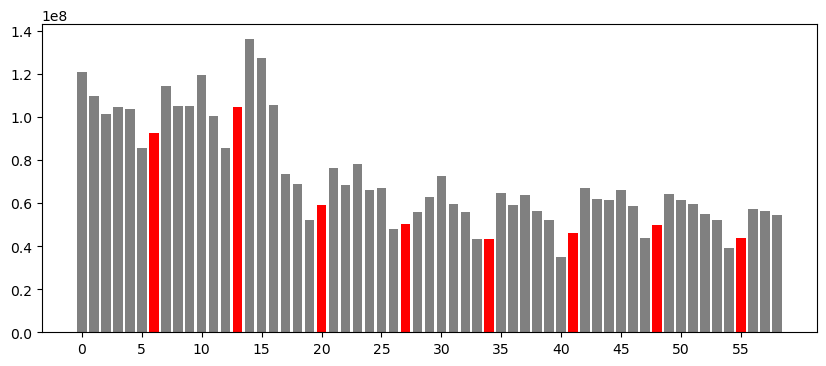

In [18]:
# корректировка дней недели по принципу (1-пн, 2-вт ... 7-вск) из предположения, что суббота - самый коммерческий день
# происходит на основании визуального определения из построенного чарта ежедневной суммарной выручки
# (красным выделен каждый седьмой день для лучшего визуального восприятия графика)
df_purchases['week'] = df_purchases['dt'] // 7
df_purchases['day_of_week'] = df_purchases['dt'] % 7 + 1

print(df_purchases.groupby(['day_of_week']).agg({'id':'nunique', 'cost':'sum'}))

c = ['grey'] * 6 + ['r']
plt.figure(figsize=(10, 4))
df_sales_to_plot = df_purchases.groupby(['week', 'day_of_week']).agg({'cost':'sum'}).reset_index()
plt.bar(df_sales_to_plot.index, df_sales_to_plot['cost'], color=c)
plt.xticks(range(0, len(df_sales_to_plot['day_of_week']), 5))
plt.show()

                id       cost
day_of_week                  
1            54795  701639921
2            48994  599804360
3            46915  558831159
4            35695  432071121
5            38717  489850834
6            57965  756733173
7            54699  712036228


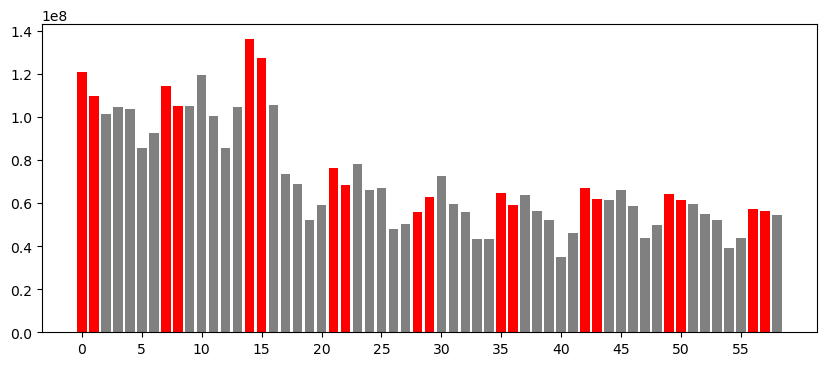

In [19]:
# корректировка нумерации по результатам анализа
df_purchases['day_of_week']  = (df_purchases['dt'] + 5) % 7 + 1
df_purchases['week']  = (df_purchases['dt'] + 5) // 7 + 1

print(df_purchases.groupby(['day_of_week']).agg({'id':'nunique', 'cost':'sum'}))

c = ['r'] * 2 + ['grey'] * 5
plt.figure(figsize=(10, 4))
df_sales_to_plot = df_purchases.groupby(['week', 'day_of_week']).agg({'cost':'sum'}).reset_index()
plt.bar(df_sales_to_plot.index, df_sales_to_plot['cost'], color=c)
plt.xticks(range(0, len(df_sales_to_plot['day_of_week']), 5))
plt.show()

In [20]:
df_purchases

,id,product,colour,cost,product_sex,base_sale,dt,week,day_of_week
0,0,"Велосипед горный женский Stern Mira 2.0 26""",белый/синий,13599,0.0,1,7,2,6
1,0,Стол Outventure,зелёный,1499,NaN,0,37,7,1
2,0,Набор Outventure: стол + 4 стула,бежевый,4799,NaN,0,37,7,1
3,3,Бутсы мужские GSD Astro,белый,1599,1.0,0,13,3,5
4,3,Мяч футбольный PUMA TEAMFINAL 21.2 FIFA QUALIT...,мультицвет,7199,NaN,0,27,5,5
...,...,...,...,...,...,...,...,...,...
786255,178004,Полуботинки мужские Ascot Vortex,хаки/черный,7999,1.0,0,12,3,4
786256,178004,Кроссовки мужские Nike Air Max 90,черный/серый,24299,1.0,0,13,3,5
786257,178004,Кроссовки мужские Nike Air Max 90,черный/серый,24299,1.0,0,20,4,5
786258,178004,Пакет,коричневый,12,NaN,0,20,4,5


# 2. Очистка и Нормализация Текстовых Признаков (Text Feature Engineering)

Сырые текстовые признаки (названия товаров, категории: колонка `product` и `product_sex`) требуют нормализации для последующей кластеризации и снижения размерности:
*   **Нормализация:** Приведение слов к единой корневой форме, регистру.
*   **Удаление шума:** Очистка от спецсимволов, лишних пробелов и стоп-слов, не несущих смысловой нагрузки.
*   **Словарь категорий:** Выделение базовых категорий из сложных вложенных строк.


In [21]:
# создание каталога продуктов df_product
df_purchases['product_id'] = df_purchases['product'].factorize()[0] + 1
df_product = df_purchases[['product_id', 'product', 'product_sex']].drop_duplicates().reset_index(drop=True)

# первичные ручные корректировки и нормализация
df_product['product'] = df_product['product'].str.strip().str.replace('  ', ' ')
df_product['product'] = df_product['product'].str.replace(r'[\"\:\,]', '', regex = True)
df_product['product'] = df_product['product'].str.lower()
df_product['product'] = df_product['product'].str.replace(r'(?<= )sup(?= |,)|^sup(?= |,)', r'сап', regex=True)
df_product['product'] = df_product['product'].str.replace(r'\bjоу\b', r'joy', regex=True)
df_product['product'] = df_product['product'].str.replace('детскиеdemix', 'детские demix')

# замена опечаток: латинские буквы в русских словах на русские
# инициирование словарей схожих символов латиницы и кириллицы
file_name = 'eng2rus_letter_dict.json'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)
with open(full_path, 'r') as f:
    eng2rus_letter_dict = json.load(f)
rus2eng_letter_dict = dict(zip(eng2rus_letter_dict.values(), eng2rus_letter_dict.keys()))

# разделение колонки 'product' по словам и сохранение в датасет df_product
df_product['words'] = df_product['product'].str.split()
df_product = df_product.explode('words').reset_index(drop=True)

# добавление колонок-идентификаторов языка, которому принадлежит слово
for col, pat in {'is_eng_word': r'[a-zA-Z]', 'is_rus_word': r'[а-яА-ЯёЁ]'}.items():
    mask_complex = df_product['words'].str.contains(r'\-|/')
    df_product.loc[~mask_complex, f'{col}'] = df_product.loc[~mask_complex, 'words'].str.count(pat) / df_product.loc[~mask_complex, 'words'].str.count(r'.')
    mask = df_product[f'{col}'] > .51
    df_product.loc[mask, f'{col}'] = 1
    mask = df_product[f'{col}'] < .49
    df_product.loc[mask, f'{col}'] = 0

# заполнение неидентифицированных слов (цифры, составные слова) значением 0 в обоих колонках языков
df_product.loc[:, ['is_rus_word', 'is_eng_word']] = df_product.loc[:, ['is_rus_word', 'is_eng_word']].fillna(0)

# замена схожих букв на корректные на основании словарей eng2rus_letter_dict и rus2eng_letter_dict
mask = df_product['is_rus_word'] == 1
df_product.loc[mask, 'words'] = df_product.loc[mask, 'words'].str.replace(r'[a-zA-Z]', lambda m: eng2rus_letter_dict[m.group()], regex=True)
mask = df_product['is_eng_word'] == 1
df_product.loc[mask, 'words'] = df_product.loc[mask, 'words'].str.replace(r'[а-яА-ЯёЁ]', lambda m: rus2eng_letter_dict[m.group()], regex=True)

# корректировка признака is_rus_word для комплексных слов с дефисом
mask = df_product['words'].str.contains(r'\b[а-я]+-[а-я]+\b')
df_product.loc[mask, 'is_rus_word'] = 1

# сохранение копии расширеного датасета для дальнейшего использования при обработке данных
df_product_exploded = df_product.copy()

# свертывание слов обратно в текст колонки 'product' и подмена его в датасете df_product
df_product = df_product.groupby('product_id').agg({
    'words':list,
    'product_sex':'first'
}).reset_index()#[['product']]#.str.join(' ')
df_product['product'] = df_product['words'].str.join(' ')
df_product.drop(columns=['words'], inplace=True)
df_product

,product_id,product_sex,product
0,1,0.0,велосипед горный женский stern mira 2.0 26
1,2,NaN,стол outventure
2,3,NaN,набор outventure стол + 4 стула
3,4,1.0,бутсы мужские gsd astro
4,5,NaN,мяч футбольный puma teamfinal 21.2 fifa qualit...
...,...,...,...
23140,23141,NaN,рюкзак jack wolfskin kalari kingston kit 56+16
23141,23142,NaN,батончик протеиновый forsio 40 г 30 шт.
23142,23143,NaN,клюшка детская bauer vapor 3x flex 55 p92
23143,23144,1.0,футболка мужская reebok united by fitness


In [22]:
# инициализация колонки 'prod_adults' на основании текстовых фильтров, идентифицирующих признак товаров для взрослых
mask_man = df_product['product'].str.contains(r'\bм(?=у(\b|ж)|ж)|\bmen\'| men\b', case=False)   # фильтр для поиска мужчин
mask_woman = df_product['product'].str.contains(r'\bж(?=е(\b|н)|н)|\bж\b|wom', case=False)      # фильтр для поиска женщин
mask_adult = df_product['product'].str.contains(r'\badul|\bвзрос', case=False)                  # фильтр для обобщенного поиска
df_product['prod_adults'] = (mask_adult | mask_man | mask_woman) * 1

# инициализация колонки 'prod_kids' на основании текстовых фильтров, идентифицирующих признак товаров для детей
mask_boy = df_product['product'].str.contains(r'\bмальч|\bboy(?=\b|s)', case=False)
mask_girl = df_product['product'].str.contains(r'\bдевоч|\bgirl(?=\b|s)', case=False)
mask_kids = df_product['product'].str.contains(r'\bдет|\bподр|\bkid|\bchild|\binfa|\bteen', case=False)
df_product['prod_kids'] = (mask_kids | mask_boy | mask_girl) * 1

# создание разреженной кросс матрицы для разделения гендерных признаков товара
s_women, s_men = pd.crosstab(df_product.index, df_product['product_sex'], dropna=False).iloc[:, :2].to_numpy().T
# инициализация гендерных колонок
df_product['prod_men'] = (mask_man | s_men) * 1
df_product['prod_women'] = (mask_woman | s_women) * 1
df_product['prod_boys'] = mask_boy * 1
df_product['prod_girls'] = mask_girl * 1

# извлечение наименования бренда по принципу бренд = первое английское слово
s_product_brand = df_product['product'].str.extract(r'(\bblack \w+|\bgreen \w+|\bblue \w+|\bnew \w+|\bthe \w*|\b[A-Za-z]+-*\w+)', expand=False).fillna('noname')
# корректировка: поиск топ 200 брендов среди извлеченных в колонке 'product'
# и корректировка наименования брендов на основании найденного
top_brands_list = s_product_brand.value_counts()[:200].index.to_list()
text = [re.escape(val) for val in top_brands_list]
pattern =r'\b' + r'\b|\b'.join(text) + r'\b'
s_product_brand_uploaded = df_product['product'].str.extract(f'({pattern})')[0]
mask = s_product_brand_uploaded.notna()
s_product_brand[mask] = s_product_brand_uploaded[mask]
df_product['product_brand'] = s_product_brand

# удаление исходного артифакта на базе которого генерировались гендерные признаки товара
df_product.drop('product_sex', axis=1, inplace=True)

/var/folders/hn/ymhf6p891c16lk59vz1f0m9m0000gn/T/ipykernel_6541/2612627561.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_man = df_product['product'].str.contains(r'\bм(?=у(\b|ж)|ж)|\bmen\'| men\b', case=False)   # фильтр для поиска мужчин
/var/folders/hn/ymhf6p891c16lk59vz1f0m9m0000gn/T/ipykernel_6541/2612627561.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_woman = df_product['product'].str.contains(r'\bж(?=е(\b|н)|н)|\bж\b|wom', case=False)      # фильтр для поиска женщин


In [23]:
df_product

,product_id,product,prod_adults,prod_kids,prod_men,prod_women,prod_boys,prod_girls,product_brand
0,1,велосипед горный женский stern mira 2.0 26,1,0,0,1,0,0,stern
1,2,стол outventure,0,0,0,0,0,0,outventure
2,3,набор outventure стол + 4 стула,0,0,0,0,0,0,outventure
3,4,бутсы мужские gsd astro,1,0,1,0,0,0,gsd
4,5,мяч футбольный puma teamfinal 21.2 fifa qualit...,0,0,0,0,0,0,puma
...,...,...,...,...,...,...,...,...,...
23140,23141,рюкзак jack wolfskin kalari kingston kit 56+16,0,0,0,0,0,0,jack
23141,23142,батончик протеиновый forsio 40 г 30 шт.,0,0,0,0,0,0,forsio
23142,23143,клюшка детская bauer vapor 3x flex 55 p92,0,1,0,0,0,0,bauer
23143,23144,футболка мужская reebok united by fitness,1,0,1,0,0,0,reebok


In [24]:
# функция извлечения русского наименования продукта из колонки 'product' датасета df_product
def product_name_extractor(df_product_exploded, df_product, speech_part_dict):
    df_product_exploded.drop('speech_part', errors='ignore', axis=1, inplace=True)
    df_product.drop('product_name', errors='ignore', axis=1, inplace=True)

    mask = df_product_exploded['is_rus_word'] == 1
    df_product_exploded.loc[mask, 'speech_part'] = df_product_exploded.loc[mask, 'words'].replace(speech_part_dict)

    mask = df_product_exploded['speech_part'] == 'NOUN'
    df_product_name = df_product_exploded\
        .loc[mask, ['product_id', 'speech_part', 'words', 'product']]\
        .drop_duplicates(['product_id', 'speech_part'])[['product_id', 'words']]\
        .reset_index(drop=True).rename(columns={'words': 'product_name'})
    df_product = pd.merge(df_product, df_product_name, on='product_id', how='left')
    return df_product

#### Извлечение Корневых Названий Товаров

Блок кода ниже отвечает за парсинг и стандартизацию названий товаров с использованием методов обработки естественного языка (NLP).

**Основные шаги алгоритма:**
1. Скрипт запрашивает у пользователя (аналитика) решение — пересчитать частотные словари названий с нуля или загрузить уже готовый результат из `speech_part_list.json`. Это значительно экономит время при повторных запусках ноутбука (Time Optimization).
2. **Морфологический анализ (spaCy POS Tagging):** При пересчете, загружается русскоязычная языковая модель `ru_core_news_sm` из библиотеки **spaCy**. Алгоритм разбивает сырые строки товаров на слова и определяет их часть речи (Part of Speech — POS), например, существительное (`NOUN`) или прилагательное (`ADJ`).
3. **Фильтрация и экстракция:** На базе словаря частей речи кастомная функция `product_name_extractor` извлекает главное существительное (корень), отбрасывая описательные прилагательные (например, из "Кроссовки беговые мужские" извлекается только "Кроссовки").
4. **Ручная валидация:** Для слов, которые не удалось опознать (различные опечатки, слэнг, аббревиатуры), применяется альтернативный механизм с регулярными выражениями. Пользователю предлагается вручную промаркировать спорные `ADJ` как `NOUN` в консоли. Итоговый словарь сохраняется на диск.
5. **Обработка исключений:** Оставшиеся неустановленные значения (`NaN`) безопасно заменяются на `'неизвестно'`.


In [25]:
req_upload = input('Хотите обновить словари названий (y или д) или загрузить существующие (н или n)?')

file_name = 'speech_part_list.json'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

if req_upload.lower() == 'y' or req_upload.lower() == 'д':
    morph_model = spacy.load('ru_core_news_sm')
    mask = df_product_exploded['is_rus_word'] == 1
    word_list = df_product_exploded.loc[mask, 'words'].unique()
    morph_iter = morph_model.pipe(word_list)
    speech_part_list = [m[0].pos_ for m in morph_iter]
    speech_part_dict = dict(zip(word_list, speech_part_list))
    with open(full_path, 'w') as f:
        json.dump(speech_part_dict, f)


    df_product = product_name_extractor(df_product_exploded, df_product, speech_part_dict)

    mask = df_product['product_name'].isna()
    speach_prt_manual_lst = df_product.loc[mask, 'product'].str.extract(r'(^[а-я]+-*[а-я]*)')[0].value_counts().index.tolist()
    for w in speach_prt_manual_lst:
        sp_part = morph_model(w)[0].pos_
        if sp_part != 'ADJ':
            speech_part_dict[f'{w}'] = 'NOUN'
        else:
            resp = input(f'Заменить признак у слова {w} на "NOUN" (y/n, д/н)')
            if resp.lower() == 'y' or resp.lower() == 'д':
                speech_part_dict[f'{w}'] = 'NOUN'
    with open(full_path, 'w') as f:
        json.dump(speech_part_dict, f)
else:
    with open(full_path, 'r') as f:
        speech_part_dict = json.load(f)

df_product = product_name_extractor(df_product_exploded, df_product, speech_part_dict)

mask = df_product['product_name'].isna()
df_product.loc[mask, 'product_name'] = 'неизвестно'

df_product

,product_id,product,prod_adults,prod_kids,prod_men,prod_women,prod_boys,prod_girls,product_brand,product_name
0,1,велосипед горный женский stern mira 2.0 26,1,0,0,1,0,0,stern,велосипед
1,2,стол outventure,0,0,0,0,0,0,outventure,стол
2,3,набор outventure стол + 4 стула,0,0,0,0,0,0,outventure,набор
3,4,бутсы мужские gsd astro,1,0,1,0,0,0,gsd,бутсы
4,5,мяч футбольный puma teamfinal 21.2 fifa qualit...,0,0,0,0,0,0,puma,мяч
...,...,...,...,...,...,...,...,...,...,...
23140,23141,рюкзак jack wolfskin kalari kingston kit 56+16,0,0,0,0,0,0,jack,рюкзак
23141,23142,батончик протеиновый forsio 40 г 30 шт.,0,0,0,0,0,0,forsio,батончик
23142,23143,клюшка детская bauer vapor 3x flex 55 p92,0,1,0,0,0,0,bauer,клюшка
23143,23144,футболка мужская reebok united by fitness,1,0,1,0,0,0,reebok,футболка


In [26]:
df_product[mask]

,product_id,product,prod_adults,prod_kids,prod_men,prod_women,prod_boys,prod_girls,product_brand,product_name
3674,3675,low shoes for men caterpillar downlink canvas ...,1,0,1,0,0,0,caterpillar,неизвестно
6279,6280,gladiator origin 12.6t sc,0,0,0,0,0,0,gladiator,неизвестно
7536,7537,women's beach jumpsuit termit blue/green,1,0,0,1,0,0,termit,неизвестно
7537,7538,sneakers for women puma rbd game low white/gra...,1,0,0,1,0,0,puma,неизвестно
7538,7539,women's t-shirt outventure bright blue,1,0,0,1,0,0,outventure,неизвестно
7539,7540,t-shirt for boys termit red,0,1,0,0,1,0,termit,неизвестно
7540,7541,men's windbreaker outventure dark blue color,1,0,1,0,0,0,outventure,неизвестно
7541,7542,puma 4keeps sports bra top lavender color,0,0,0,0,0,0,puma,неизвестно
7542,7543,sports bra top demix purple color,0,0,0,0,0,0,demix,неизвестно
11196,11197,gladiator pro 12.6t,0,0,0,0,0,0,gladiator,неизвестно


In [27]:
# фильтр (см вывод данных выше) по незаполненным наименованиям продуктов выявляет, что эти наименования не имеют русского перевода в данных
mask = df_product['product_name'] == 'неизвестно'
prod_eng_list = df_product.loc[mask, 'product'].tolist()

# перевод иностранных описаний наименований на русский язык с помощью библиотеки GoogleTranslator
translator = GoogleTranslator('auto', 'ru')
prod_translated_list = translator.translate_batch(prod_eng_list)

# замена переведенных значений на уникальные наименования товаров
pattern = '|'.join([fr'\b{re.escape(rf'{p}')}\b' for p in df_product['product_name'].unique()])
df_product.loc[mask, 'product_name'] = pd.Series(prod_translated_list)\
    .str.lower()\
    .str.extract(f'({pattern})', expand=False)\
    .fillna('неизвестно').tolist()

# ручная корректировка оставшихся наименований (1 шт)
df_product.loc[df_product['product'] == 'puma 4keeps sports bra top lavender color', 'product_name'] = 'топ'

In [28]:
# анализ оставшихся неизвестных наименований
mask = df_product['product_name'] == 'неизвестно'
df_product[mask]

,product_id,product,prod_adults,prod_kids,prod_men,prod_women,prod_boys,prod_girls,product_brand,product_name
6279,6280,gladiator origin 12.6t sc,0,0,0,0,0,0,gladiator,неизвестно
11196,11197,gladiator pro 12.6t,0,0,0,0,0,0,gladiator,неизвестно
12018,12019,gladiator pro 11.2,0,0,0,0,0,0,gladiator,неизвестно
12648,12649,gladiator elite 11.2,0,0,0,0,0,0,gladiator,неизвестно
13387,13388,gladiator origin 10.6sc,0,0,0,0,0,0,gladiator,неизвестно
13389,13390,gladiator elite 12.6s,0,0,0,0,0,0,gladiator,неизвестно
14478,14479,gladiator elite 14.0s,0,0,0,0,0,0,gladiator,неизвестно
15265,15266,gladiator wind 10.7,0,0,0,0,0,0,gladiator,неизвестно
16313,16314,gladiator duo 15.2,0,0,0,0,0,0,gladiator,неизвестно
16872,16873,gladiator origin 12.6s sc,0,0,0,0,0,0,gladiator,неизвестно


In [29]:
# замена значений 'неизвестно' наиболее частыми значениями в рамках бренда
s_most_frequent_product = df_product.groupby('product_brand')['product_name'].transform(lambda x: x.mode()[0])
mask = df_product['product_name'] == 'неизвестно'
df_product.loc[mask, 'product_name'] = s_most_frequent_product.loc[mask]
df_product[mask]

,product_id,product,prod_adults,prod_kids,prod_men,prod_women,prod_boys,prod_girls,product_brand,product_name
6279,6280,gladiator origin 12.6t sc,0,0,0,0,0,0,gladiator,сап
11196,11197,gladiator pro 12.6t,0,0,0,0,0,0,gladiator,сап
12018,12019,gladiator pro 11.2,0,0,0,0,0,0,gladiator,сап
12648,12649,gladiator elite 11.2,0,0,0,0,0,0,gladiator,сап
13387,13388,gladiator origin 10.6sc,0,0,0,0,0,0,gladiator,сап
13389,13390,gladiator elite 12.6s,0,0,0,0,0,0,gladiator,сап
14478,14479,gladiator elite 14.0s,0,0,0,0,0,0,gladiator,сап
15265,15266,gladiator wind 10.7,0,0,0,0,0,0,gladiator,сап
16313,16314,gladiator duo 15.2,0,0,0,0,0,0,gladiator,сап
16872,16873,gladiator origin 12.6s sc,0,0,0,0,0,0,gladiator,сап


In [30]:
df_product

,product_id,product,prod_adults,prod_kids,prod_men,prod_women,prod_boys,prod_girls,product_brand,product_name
0,1,велосипед горный женский stern mira 2.0 26,1,0,0,1,0,0,stern,велосипед
1,2,стол outventure,0,0,0,0,0,0,outventure,стол
2,3,набор outventure стол + 4 стула,0,0,0,0,0,0,outventure,набор
3,4,бутсы мужские gsd astro,1,0,1,0,0,0,gsd,бутсы
4,5,мяч футбольный puma teamfinal 21.2 fifa qualit...,0,0,0,0,0,0,puma,мяч
...,...,...,...,...,...,...,...,...,...,...
23140,23141,рюкзак jack wolfskin kalari kingston kit 56+16,0,0,0,0,0,0,jack,рюкзак
23141,23142,батончик протеиновый forsio 40 г 30 шт.,0,0,0,0,0,0,forsio,батончик
23142,23143,клюшка детская bauer vapor 3x flex 55 p92,0,1,0,0,0,0,bauer,клюшка
23143,23144,футболка мужская reebok united by fitness,1,0,1,0,0,0,reebok,футболка


# 3. Инжиниринг Цветовых Признаков и математическая интерпретация цветового пространства

Работа с цветом усложняется тем, что исходные данные содержат множество сложных или редких оттенков (например, "blue/lightblue/gold"). Для снижения размерности категориального признака применяется математический подход:
1.  **Парсинг составных цветов:** Разделение строк вроде 'сине-зеленый', на списки базовых цветов.
2.  **Нормализация:** Приведение наименований цветов к единой корневой форме и регистру, расшифровка сокращений.
3.  **Удаление шума:** Очистка от спецсимволов, лишних пробелов и стоп-слов, не несущих смысловой нагрузки.
2.  **Отделение модификаторов цвета:** извлечение признаков, модифицирующих цвет в отдельную бинарную кросс матрицу в рамках датасета.
2.  **Трансформация цветового пространства:** Перевод из сырых строковых названий в RGB, а затем в пространство **CIELAB (L*a*b*)** — оно точнее отражает человеческое восприятие цвета и, в отличие от RGB, не искажает цветовые признаки при усреднении. Для трансформации используется библиотека webcolors. Она работает только с английскими наименованиями, что требует перевода русских наименований цветов в английские
3.  **Маппинг базовых цветов (K-Nearest Neighbors):** Использование алгоритма KNN (модель `n_neighbors=1`, метрика `euclidean`) для приведения любых сложных оттенков в LAB-координатах к эталонной палитре из ограниченного числа базовых цветов (red, blue, green и т.д.).
4.  **Флагирование сложных признаков:** Создание бинарных флагов для структурных свойств одежды (`is_colour_block`, `is_multicolored`).


In [31]:
 # функция определяющая:
 # colour_set - множество цветов, представленных в описании в датасете
 # colour_eng_list - описание цвета, где встречается хоть одна латинская буква
 def unique_color_extractor(column):
    df_colour = column.str.split(r'[/-]', expand=True)
    colour_set = set()
    for col in df_colour.columns:
        colour_set |= set(df_colour[col])
    colour_set -= {None}
    colour_eng_list = [re.findall(r'\b[A-Za-z]+', i)[0] for i in list(colour_set) if len(re.findall(r'\b[A-Za-z]+', i))!=0]
    return colour_set, colour_eng_list

In [32]:
# анализ результатов colour_eng_list показал
# наличие опечаток из-за путаницы в написании букв из-за их визуальной схожести (с-с проклятие)
colour_set, colour_eng_list = unique_color_extractor(df_purchases['colour'])
mask = df_purchases['colour'].fillna('unknown').str.contains('|'.join(colour_eng_list))
df_purchases.loc[mask, 'colour']

18310                   PEL
66446                  HTPK
67064                  PEHL
100904    cеребряный/черный
100905    cеребряный/черный
106983                  HPS
107051    cеребряный/черный
114709                    S
114726                    S
129638                   PK
131589                 HTPK
134656    cеребряный/черный
135833                   BG
176979                 HTPK
177454                   BG
221573                  BGH
229417                   CB
236812                 PWRT
244510                  GSU
253473                 HTPK
253478                   FT
253899    cеребряный/черный
282824                  INC
289812                   CH
313356                    G
332927                   FT
337086                   HT
382417                    C
414749                 PWRT
414914                 HTPK
417705                    C
436280    cеребряный/черный
436942                    G
446441                  RBS
475460                   BG
485723              

In [33]:
colour_eng_list

['BGH',
 'BG',
 'PEL',
 'RBS',
 'FT',
 'PWRT',
 'HPS',
 'c',
 'PK',
 'CB',
 'SB',
 'GSU',
 'MBT',
 'HT',
 'HTPK',
 'TR',
 'CH',
 'ROL',
 'DBP',
 'G',
 'S',
 'C',
 'PEHL',
 'GAU',
 'INC',
 'FTGPK']

In [34]:
# поскольку опечаток немного, применена их ручная чистка
# в дальнейшем алгоритм лучше изменить на более надежный (выходит за рамки текущей задачи)
df_purchases['colour'] = df_purchases['colour'].str.replace('cеребряный', 'серебряный')

In [35]:
# повторная проверка содержимого списка английских цветовых наименований
colour_set, colour_eng_list = unique_color_extractor(df_purchases['colour'])
mask = df_purchases['colour'].fillna('unknown').str.contains('|'.join(colour_eng_list))
df_purchases.loc[mask, 'colour']

18310       PEL
66446      HTPK
67064      PEHL
106983      HPS
114709        S
114726        S
129638       PK
131589     HTPK
135833       BG
176979     HTPK
177454       BG
221573      BGH
229417       CB
236812     PWRT
244510      GSU
253473     HTPK
253478       FT
282824      INC
289812       CH
313356        G
332927       FT
337086       HT
382417        C
414749     PWRT
414914     HTPK
417705        C
436942        G
446441      RBS
475460       BG
485723     HTPK
505314       CH
517739       CH
554920      DBP
564401       TR
585176        C
585178        C
602466     HTPK
604055       SB
619523      ROL
632128      MBT
638788      ROL
646139      GAU
658185     HTPK
681613    FTGPK
715540       CH
716543      GAU
734074     HTPK
774917       CH
782726     HTPK
Name: colour, dtype: object

In [36]:
# анализ английских цветовых наименований выявил,
# что они имеют признаки мультицвета (перламутровые свойства) и принадлежат товарам для рыбалки
# теоретически при моделировании и машинном обучении, модели можно напрямую передать эти свойства
# здесь это не сделано, поскольку доля таких случаев пренебрежительно мала
print(pd.concat((df_purchases.loc[mask, 'colour'], df_purchases.loc[mask, 'product']), axis=1).drop_duplicates('colour'))

       colour                                            product
18310     PEL  Воблер Rapala X-Rap Haku 14/PEL/тонущий/14см, ...
66446    HTPK  Воблер Rapala Twitchin' Rap 12/HTPK/медленно т...
67064    PEHL  Воблер Rapala Shallow Shad Rap 09/PEHL/плавающ...
106983    HPS  Воблер Rapala Twitchin' Rap 12/HPS/медленно то...
114709      S  Блесна вращающаяся Blue Fox Minnow Super Vibra...
129638     PK  Незацепляйка Rapala Rattlin' Minnow Spoon 08/P...
135833     BG  Незацепляйка Rapala Rattlin' Minnow Spoon 08/B...
221573    BGH  Воблер Rapala X-Rap Twichin' Shad 08/BGH/медле...
229417     CB  Блесна вращающаяся Blue Fox Minnow Super Vibra...
236812   PWRT  Незацепляйка Rapala Rattlin' Minnow Spoon 08/P...
244510    GSU  Незацепляйка Rapala Rattlin' Minnow Spoon 08/G...
253478     FT    Тейл спиннер Storm GOMOKU Spin 06/FT/4,5см, 6гр
282824    INC    Тейл спиннер Storm GOMOKU Spin 16/INC/6см, 16гр
289812     CH  Незацепляйка Rapala Rattlin' Minnow Spoon 08/C...
313356      G  Блесна вра

In [37]:
# анализ списка русских наименований цветов
colour_rus_list = sorted(list(colour_set - set(colour_eng_list)))
colour_rus_list

['Бежевый',
 'Белый',
 'Голубой',
 'Желтый',
 'Зеленый',
 'Коричневый',
 'Красный',
 'Лимонный',
 'Мультицвет',
 'Оранжевый',
 'Разноцветный',
 'Розовый',
 'Серебряный',
 'Серый',
 'Синий',
 'Тёмно',
 'Фиолетовый',
 'Черный',
 'абрикосовый',
 'авокадо',
 'аквамарин',
 'алый',
 'антрацит',
 'антрацитовый',
 'асфальтовый',
 'бeлый',
 'баклажановый',
 'бежевый',
 'бело',
 'белый',
 'бесцветный',
 'бирюзово',
 'бирюзовый',
 'бледно',
 'болотный',
 'бордо',
 'бордово',
 'бордовый',
 'бронзовый',
 'бургунди',
 'варио',
 'васильковый',
 'вереск',
 'винный',
 'виноградный',
 'вишневый',
 'вишнёвый',
 'водно',
 'волна',
 'волны',
 'вольт',
 'глиняный',
 'глянцевый',
 'голубо',
 'голубой',
 'горчичный',
 'гранитный',
 'графит',
 'графитовый',
 'грязно',
 'дай',
 'дерево',
 'джунгли',
 'дымчатый',
 'ежевичный',
 'елово',
 'еловый',
 'желто',
 'желтый',
 'жемчужно',
 'жёлтый',
 'зебра',
 'зелено',
 'зеленый',
 'зелёный',
 'зеркальный',
 'золотистый',
 'золото',
 'золотой',
 'изумрудно',
 'изумрудн

In [38]:
 # поиск сокращений или пояснений, обернутых в скобки в списках цветов и помещение их в список сокращений shortcut_list
colour_rus_str = ' '.join(colour_rus_list).lower()
shortcut_list = re.findall(r'[а-яё]+\.|\([а-яё]+\)', colour_rus_str)
shortcut_list

['св.']

In [39]:
# создание признака поиска из всех значений shortcut_list
pattern_to_replace = '|'.join([re.escape(p) for p in shortcut_list])
pattern_to_replace

'св\\.'

In [40]:
# удаление сокращений, упомянутых в двух предыдущих ячейках с кодом в списке русских наименований цвета
colour_rus_list = re.sub(pattern_to_replace, '', colour_rus_str).split(' ')
colour_rus_list

['бежевый',
 'белый',
 'голубой',
 'желтый',
 'зеленый',
 'коричневый',
 'красный',
 'лимонный',
 'мультицвет',
 'оранжевый',
 'разноцветный',
 'розовый',
 'серебряный',
 'серый',
 'синий',
 'тёмно',
 'фиолетовый',
 'черный',
 'абрикосовый',
 'авокадо',
 'аквамарин',
 'алый',
 'антрацит',
 'антрацитовый',
 'асфальтовый',
 'бeлый',
 'баклажановый',
 'бежевый',
 'бело',
 'белый',
 'бесцветный',
 'бирюзово',
 'бирюзовый',
 'бледно',
 'болотный',
 'бордо',
 'бордово',
 'бордовый',
 'бронзовый',
 'бургунди',
 'варио',
 'васильковый',
 'вереск',
 'винный',
 'виноградный',
 'вишневый',
 'вишнёвый',
 'водно',
 'волна',
 'волны',
 'вольт',
 'глиняный',
 'глянцевый',
 'голубо',
 'голубой',
 'горчичный',
 'гранитный',
 'графит',
 'графитовый',
 'грязно',
 'дай',
 'дерево',
 'джунгли',
 'дымчатый',
 'ежевичный',
 'елово',
 'еловый',
 'желто',
 'желтый',
 'жемчужно',
 'жёлтый',
 'зебра',
 'зелено',
 'зеленый',
 'зелёный',
 'зеркальный',
 'золотистый',
 'золото',
 'золотой',
 'изумрудно',
 'изумрудн

In [41]:
# поскольку единственное найденное сокращение относится к модификатору, оно обработано вручную
# для этого заведен словарь сокращений shortcut_dict
shortcut_dict = {
    'св.':'светло-'
}
pattern = '|'.join([re.escape(p) for p in shortcut_dict])
pattern

'св\\.'

In [42]:
# замена сокращений на полное наименование из словаря сокращений
df_purchases['colour'] = df_purchases['colour'].str.replace(pattern, lambda m: shortcut_dict[m.group()], regex=True)

In [43]:
colour_eng_list

['BGH',
 'BG',
 'PEL',
 'RBS',
 'FT',
 'PWRT',
 'HPS',
 'PK',
 'CB',
 'SB',
 'GSU',
 'MBT',
 'HT',
 'HTPK',
 'TR',
 'CH',
 'ROL',
 'DBP',
 'G',
 'S',
 'C',
 'PEHL',
 'GAU',
 'INC',
 'FTGPK']

In [45]:
# перевод уникальных русских наименований цветов и их модификаторов при помощи библиотеки GoogleTranslator
# и инициализация внутреннего словаря переводов для того, чтобы избегать постоянного обращения к GoogleTranslator в будущем
translator = GoogleTranslator('ru')
colour_eng_list = translator.translate_batch(colour_rus_list)
colour_dict = {rus:eng.lower() for rus, eng in zip(colour_rus_list, colour_eng_list)}
colour_dict

{'бежевый': 'beige',
 'белый': 'white',
 'голубой': 'blue',
 'желтый': 'yellow',
 'зеленый': 'green',
 'коричневый': 'brown',
 'красный': 'red',
 'лимонный': 'citric',
 'мультицвет': 'multicolor',
 'оранжевый': 'orange',
 'разноцветный': 'colorful',
 'розовый': 'pink',
 'серебряный': 'silver',
 'серый': 'grey',
 'синий': 'blue',
 'тёмно': 'dark',
 'фиолетовый': 'violet',
 'черный': 'black',
 'абрикосовый': 'apricot',
 'авокадо': 'avocado',
 'аквамарин': 'aquamarine',
 'алый': 'scarlet',
 'антрацит': 'anthracite',
 'антрацитовый': 'anthracite',
 'асфальтовый': 'asphalt',
 'бeлый': 'white',
 'баклажановый': 'eggplant',
 'бело': 'white',
 'бесцветный': 'colorless',
 'бирюзово': 'turquoise',
 'бирюзовый': 'turquoise',
 'бледно': 'pale',
 'болотный': 'swamp',
 'бордо': 'bordeaux',
 'бордово': 'burgundy',
 'бордовый': 'burgundy',
 'бронзовый': 'bronze',
 'бургунди': 'burgundy',
 'варио': 'vario',
 'васильковый': 'cornflower',
 'вереск': 'heather',
 'винный': 'wine',
 'виноградный': 'grape',


In [46]:
# ручная обработка наименований, с переводом которых не справился GoogleTranslator
colour_dict['голубой'] = 'lightblue'
colour_dict['голубо'] = 'lightblue'
colour_dict['разноцветный'] = 'multicolor'
colour_dict['бордо'] = 'burgundy'
colour_dict['волны'] = 'waves'
colour_dict['дай'] = 'dye'
colour_dict['жемчужно'] = 'pearl'
colour_dict['золотистый'] = 'gold'
colour_dict['кремово'] = 'cream'
colour_dict['леопардовый'] = 'leopard'
colour_dict['масляно'] = 'oil'
colour_dict['металлический'] = 'metallic'
colour_dict['молочно'] = 'milk'
colour_dict['молочный'] = 'milk'
colour_dict['песочно'] = 'sand'
colour_dict['полоски'] = 'strip'
colour_dict['цветной'] = 'multicolor'
colour_dict['салатовый'] = 'lightgreen'
colour_dict['камо'] = 'camouflage'
colour_dict['пепельно'] = 'ashen'
colour_dict['хром'] = 'chrome'
colour_dict['хромовый'] = 'chrome'
colour_dict['циан'] = 'cyan'
colour_dict['тёмно'] = 'dark'
#colour_dict['лимонно'] = 'lemon'

colour_dict

{'бежевый': 'beige',
 'белый': 'white',
 'голубой': 'lightblue',
 'желтый': 'yellow',
 'зеленый': 'green',
 'коричневый': 'brown',
 'красный': 'red',
 'лимонный': 'citric',
 'мультицвет': 'multicolor',
 'оранжевый': 'orange',
 'разноцветный': 'multicolor',
 'розовый': 'pink',
 'серебряный': 'silver',
 'серый': 'grey',
 'синий': 'blue',
 'тёмно': 'dark',
 'фиолетовый': 'violet',
 'черный': 'black',
 'абрикосовый': 'apricot',
 'авокадо': 'avocado',
 'аквамарин': 'aquamarine',
 'алый': 'scarlet',
 'антрацит': 'anthracite',
 'антрацитовый': 'anthracite',
 'асфальтовый': 'asphalt',
 'бeлый': 'white',
 'баклажановый': 'eggplant',
 'бело': 'white',
 'бесцветный': 'colorless',
 'бирюзово': 'turquoise',
 'бирюзовый': 'turquoise',
 'бледно': 'pale',
 'болотный': 'swamp',
 'бордо': 'burgundy',
 'бордово': 'burgundy',
 'бордовый': 'burgundy',
 'бронзовый': 'bronze',
 'бургунди': 'burgundy',
 'варио': 'vario',
 'васильковый': 'cornflower',
 'вереск': 'heather',
 'винный': 'wine',
 'виноградный': 'g

In [47]:
# замена всех русских наименований в df_purchases['colour'] на английские
# и запись их в отдельную колонку  df_purchases['colour_eng']
pattern =r'\b' + r'\b|\b'.join(colour_dict.keys()) + r'\b'
df_purchases['colour_eng'] = df_purchases['colour'].str.lower().str.replace(pattern, lambda m: colour_dict[m.group()], regex=True)
df_purchases['colour_eng'] = df_purchases['colour_eng'].fillna('unknown')
# создание id английского наименования цвета (для дальнейшей автономной работы с колонкой df_purchases['colour_eng'])
# в целях экономии времени при обработке big data
df_purchases['colour_id'] = df_purchases['colour_eng'].factorize()[0] + 1

In [48]:
# ручное создание словаря модификаторов на основании данных colour_dict
modifier_dict = {
    'is_dark':['dark'],
    'is_light':['light'],
    'is_texture':['pile', 'cell', 'strip', 'print', 'dot', 'tattoo', 'wave', 'waves', 'spider', 'vario', 'zebra'],
    'is_uncertain':['dirty', 'uncertain', 'unknown', 'colorless'],
    'is_rare':['gently', 'transparent', 'taiday'],
    'is_neutral':['dusty', 'pale'],
    'is_pastel':['pastel'],
    'is_bright':['bright', 'dye', 'acidic', 'neon'],
    'is_multicolored':['multicolor', 'multicolour'],
    'is_iridescent':['iridescent', 'glossy', 'chameleon', 'mirror']
}

# общий список уникальных модификаторов
modifier_list = [i for ls in modifier_dict.values() for i in ls]

# исправление признаков типа dark/blue, blue/dark/blue, blue/dark на dark blue, blue/dark blue, blue dark
# поскольку модификатор типа dark выступает как отдельная часть цветового блока типа цвет1/цвет2, что некорректно
# проверяются все модификаторы из созданного списка modifier_list (не только dark)
pattern_1 = r'(?<=/' + r')/|(?<=/'.join(modifier_list) + r')/'          # тип dark/blue
pattern_2 = r'(?<=^' + r')/|(?<=^'.join(modifier_list) + r')/'          # тип blue/dark/blue
pattern_3 = r'/(?=' + r'$)|/(?='.join(modifier_list) + r'$)'            # тип blue/dark
pattern = fr'{pattern_1}|{pattern_2}|{pattern_3}'
df_purchases['colour_eng'] = df_purchases['colour_eng'].str.replace(pattern, ' ', regex=True)

In [49]:
df_purchases

,id,product,colour,cost,product_sex,base_sale,dt,week,day_of_week,product_id,colour_eng,colour_id
0,0,"Велосипед горный женский Stern Mira 2.0 26""",белый/синий,13599,0.0,1,7,2,6,1,white/blue,1
1,0,Стол Outventure,зелёный,1499,NaN,0,37,7,1,2,green,2
2,0,Набор Outventure: стол + 4 стула,бежевый,4799,NaN,0,37,7,1,3,beige,3
3,3,Бутсы мужские GSD Astro,белый,1599,1.0,0,13,3,5,4,white,4
4,3,Мяч футбольный PUMA TEAMFINAL 21.2 FIFA QUALIT...,мультицвет,7199,NaN,0,27,5,5,5,multicolor,5
...,...,...,...,...,...,...,...,...,...,...,...,...
786255,178004,Полуботинки мужские Ascot Vortex,хаки/черный,7999,1.0,0,12,3,4,2114,khaki/black,318
786256,178004,Кроссовки мужские Nike Air Max 90,черный/серый,24299,1.0,0,13,3,5,1109,black/grey,27
786257,178004,Кроссовки мужские Nike Air Max 90,черный/серый,24299,1.0,0,20,4,5,1109,black/grey,27
786258,178004,Пакет,коричневый,12,NaN,0,20,4,5,1567,brown,61


In [50]:
# инициализация отдельного датасета для составления характеристик уникальных цветов, встречающихся в продажах  df_purchases
df_colour = df_purchases[['colour_id', 'colour_eng']].drop_duplicates().reset_index(drop=True)
# разделение записей типа цвет1/цветN на отдельные цветовые составляющие с раскрытием в вертикально
df_colour['colour_split'] = df_colour['colour_eng'].str.split('/')
df_colour = df_colour.explode('colour_split').reset_index(drop=True)
df_colour['colour_split'] = df_colour['colour_split'].str.replace(r'\W', ' ', regex=True)
df_colour

,colour_id,colour_eng,colour_split
0,1,white/blue,white
1,1,white/blue,blue
2,2,green,green
3,3,beige,beige
4,4,white,white
...,...,...,...
3657,1601,blue/lightblue/gold/yellow,lightblue
3658,1601,blue/lightblue/gold/yellow,gold
3659,1601,blue/lightblue/gold/yellow,yellow
3660,1602,black/cyan,black


In [51]:
# выделение модификаторов в отдельную колонку
pattern = r'\b' + r'\b|\b'.join(modifier_list) + r'\b'
df_colour['modifier'] = df_colour['colour_split'].str.findall(pattern).str.join(' ')
df_colour['modifier'].value_counts()

modifier
                     3274
dark                  157
light                  85
bright                 43
multicolor             23
transparent            19
pale                   12
dusty                   7
print                   7
neon                    4
pastel                  3
dirty                   3
strip                   2
mirror                  2
cell                    2
dot                     1
taiday                  1
wave                    1
bright multicolor       1
waves                   1
vario                   1
spider                  1
zebra                   1
glossy                  1
unknown                 1
gently                  1
iridescent              1
uncertain               1
colorless               1
light multicolor        1
chameleon               1
dye                     1
acidic                  1
tattoo                  1
Name: count, dtype: int64

In [52]:
# анализ частоты появления модификаторов по указывает на их нечастое появление среди унакальных описаний цветов
for pat in modifier_list:
    mask = df_purchases['colour_eng'].str.contains(pat)
    num = df_purchases.loc[mask].shape[0]
    print(f'{pat}', f'{num/df_purchases.shape[0]:.1%}')

dark 6.3%
light 4.2%
pile 0.0%
cell 0.0%
strip 0.0%
print 0.0%
dot 0.0%
tattoo 0.0%
wave 0.0%
waves 0.0%
spider 0.0%
vario 0.0%
zebra 0.0%
dirty 0.0%
uncertain 0.0%
unknown 15.2%
colorless 0.0%
gently 0.0%
transparent 0.1%
taiday 0.0%
dusty 0.1%
pale 0.0%
pastel 0.0%
bright 0.2%
dye 0.0%
acidic 0.0%
neon 0.0%
multicolor 2.7%
multicolour 0.0%
iridescent 0.0%
glossy 0.0%
chameleon 0.0%
mirror 0.0%


In [53]:
# создание колонки с цветом без модификаторов
pattern_1 = ' |'.join(modifier_list) + ' '
pattern_2 = r'\b' + r'\b| ?\b'.join(modifier_list) + r'\b'
df_colour['single_colour'] = df_colour['colour_split'].str.replace(fr'{pattern_1}|{pattern_2}', '', regex=True)
df_colour['single_colour']

0           white
1            blue
2           green
3           beige
4           white
          ...    
3657    lightblue
3658         gold
3659       yellow
3660        black
3661         cyan
Name: single_colour, Length: 3662, dtype: object

In [54]:
# артефакт проверки работы символьного паттерна (удалить)
#a = 'lightblue dark light blue red light'

#pattern_1 = ' |'.join(modifier_list) + ' '
#pattern_2 = r'\b' + r'\b| ?\b'.join(modifier_list) + r'\b'
#re.sub(fr'{pattern_1}|{pattern_2}', '', a)

In [55]:
# проверка колонки df_colour['single_colour'] на наличие символьных разделителей
mask = df_colour['single_colour'].str.contains(r'\W')
for val in df_colour.loc[mask, 'single_colour']:
    print(val)

cream white
sand olive
gray green
gray lightblue
blue green
red orange
redhead brown
sand grey
cream white
gray green
oil yellow
gray green
blue lightblue
black grey
cream white
gray lightblue
gray lightblue
turquoise beige
purple pink
gray lightblue
cream white
black gold
black white
spruce grey
gray brown
pink orange
gray lightblue
milk white
cream white
blue white
gray lightblue
yellow green
gray olive
white black
black blue
green lightblue
gray blue
orange black
black white
gray beige
black yellow
gray blue
blue lightblue
gray black
gray lightblue
orange brown
blue green
white grey
gray green
black 
gray white
black red
red pink
gray white
gray blue
gray lightblue
greyish lightblue
black brown
water green
cream white
burgundy brown
blue green
red brown
gray lightblue
pearl white
gray violet
white pink
powdery pink
blue red
lemony yellow
lightblue blue
pearl white
gray pink
ashen pink
gray orange
coral pink
ashen green
cream white
gray lightblue
pink red
gray white
emerald green
hea

In [56]:
df_colour

,colour_id,colour_eng,colour_split,modifier,single_colour
0,1,white/blue,white,,white
1,1,white/blue,blue,,blue
2,2,green,green,,green
3,3,beige,beige,,beige
4,4,white,white,,white
...,...,...,...,...,...
3657,1601,blue/lightblue/gold/yellow,lightblue,,lightblue
3658,1601,blue/lightblue/gold/yellow,gold,,gold
3659,1601,blue/lightblue/gold/yellow,yellow,,yellow
3660,1602,black/cyan,black,,black


In [57]:
# создание разреженной бинарной кросс матрицы для каждого модификатора
for mod in modifier_dict:
    if mod != 'is_uncertain':
        pattern = r'\b' + r'\b|\b'.join(modifier_dict[mod]) + r'\b'
        df_colour[f'{mod}'] = df_colour['colour_split'].str.contains(pattern) * 1
df_colour['single_colour'] = df_colour['single_colour'].str.strip().replace('  ', ' ')
df_colour = df_colour.reset_index().rename(columns={'index': 'single_colour_id'})

In [58]:
# анализ значений df_colour['single_colour'] устранения шума и извлечения модификаторов показал,
# что в данных есть информация о цвете, состаящая только из модификаторов
df_colour[df_colour['single_colour'] == '']

,single_colour_id,colour_id,colour_eng,colour_split,modifier,single_colour,is_dark,is_light,is_texture,is_rare,is_neutral,is_pastel,is_bright,is_multicolored,is_iridescent
5,5,5,multicolor,multicolor,multicolor,,0,0,0,0,0,0,0,1,0
14,14,11,unknown,unknown,unknown,,0,0,0,0,0,0,0,0,0
193,193,116,transparent,transparent,transparent,,0,0,0,1,0,0,0,0,0
420,420,232,print,print,print,,0,0,1,0,0,0,0,0,0
467,467,256,dot,dot,dot,,0,0,1,0,0,0,0,0,0
1226,1226,582,dye,dye,dye,,0,0,0,0,0,0,1,0,0
1327,1327,625,chameleon,chameleon,chameleon,,0,0,0,0,0,0,0,0,1
1487,1487,694,colorless,colorless,colorless,,0,0,0,0,0,0,0,0,0
1761,1761,808,uncertain,uncertain,uncertain,,0,0,0,0,0,0,0,0,0
2187,2187,988,taiday,taiday,taiday,,0,0,0,1,0,0,0,0,0


In [59]:
# на случай, упомянутый в предыдущей ячейке, создается признак цветовой неопределенности 'is_uncertain'
mask = df_colour['single_colour'] == ''
df_colour['is_uncertain'] = mask * 1

In [60]:
df_colour[df_colour['single_colour'] == '']

,single_colour_id,colour_id,colour_eng,colour_split,modifier,single_colour,is_dark,is_light,is_texture,is_rare,is_neutral,is_pastel,is_bright,is_multicolored,is_iridescent,is_uncertain
5,5,5,multicolor,multicolor,multicolor,,0,0,0,0,0,0,0,1,0,1
14,14,11,unknown,unknown,unknown,,0,0,0,0,0,0,0,0,0,1
193,193,116,transparent,transparent,transparent,,0,0,0,1,0,0,0,0,0,1
420,420,232,print,print,print,,0,0,1,0,0,0,0,0,0,1
467,467,256,dot,dot,dot,,0,0,1,0,0,0,0,0,0,1
1226,1226,582,dye,dye,dye,,0,0,0,0,0,0,1,0,0,1
1327,1327,625,chameleon,chameleon,chameleon,,0,0,0,0,0,0,0,0,1,1
1487,1487,694,colorless,colorless,colorless,,0,0,0,0,0,0,0,0,0,1
1761,1761,808,uncertain,uncertain,uncertain,,0,0,0,0,0,0,0,0,0,1
2187,2187,988,taiday,taiday,taiday,,0,0,0,1,0,0,0,0,0,1


In [61]:
df_colour

,single_colour_id,colour_id,colour_eng,colour_split,modifier,single_colour,is_dark,is_light,is_texture,is_rare,is_neutral,is_pastel,is_bright,is_multicolored,is_iridescent,is_uncertain
0,0,1,white/blue,white,,white,0,0,0,0,0,0,0,0,0,0
1,1,1,white/blue,blue,,blue,0,0,0,0,0,0,0,0,0,0
2,2,2,green,green,,green,0,0,0,0,0,0,0,0,0,0
3,3,3,beige,beige,,beige,0,0,0,0,0,0,0,0,0,0
4,4,4,white,white,,white,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3657,3657,1601,blue/lightblue/gold/yellow,lightblue,,lightblue,0,0,0,0,0,0,0,0,0,0
3658,3658,1601,blue/lightblue/gold/yellow,gold,,gold,0,0,0,0,0,0,0,0,0,0
3659,3659,1601,blue/lightblue/gold/yellow,yellow,,yellow,0,0,0,0,0,0,0,0,0,0
3660,3660,1602,black/cyan,black,,black,0,0,0,0,0,0,0,0,0,0


In [62]:
# создание датасета df_rgb для мэппинга RGB по наименованию цвета
df_rgb = df_colour[['single_colour']].reset_index().rename(columns={'index':'single_colour_id'}).copy()
df_rgb['compound_colors'] = df_rgb['single_colour'].str.split(' ')
df_rgb = df_rgb.explode('compound_colors').reset_index(drop=True)

# извлечение RGB информации из библиотеки webcolors (работает только с английскими наименованиями цветов)
rgb_list = []
for c in df_rgb['compound_colors']:
    try:
        rgb_list += [tuple(webcolors.name_to_rgb(c))]
    except ValueError:
        rgb_list += [np.nan]
df_rgb['colour_rgb'] = rgb_list

# извлечение RGB информации по цветам, которые не вошли в webcolors из внутреннего мануального словаря
file_name = 'color_rgbs.json'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

with open(full_path, 'r') as f:
    colour_rgbs_dict = json.load(f)
mask = df_rgb['colour_rgb'].isna()
df_rgb.loc[mask, 'colour_rgb'] = df_rgb.loc[mask, 'compound_colors'].map(colour_rgbs_dict)

# извлечение RGB информации по цветам товаров для рыбалки на основании датасета, составленного вручную (мануального)
file_name = 'fishing_colors.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_fishing_colors = pd.read_csv(full_path, usecols=[0,1])
df_fishing_colors['colour_rgb'] = df_fishing_colors['colour_rgb'].str.replace(r'\(|\)', '', regex=True).str.split(',').apply(lambda x: np.array([int(i) for i in x]))
mask_val_list = df_fishing_colors['single_colour'].unique()
mask = df_rgb['single_colour'].isin(mask_val_list)
fishing_colors_dict = df_fishing_colors.set_index('single_colour').to_dict()['colour_rgb']
df_rgb.loc[mask, 'colour_rgb'] = df_rgb.loc[mask, 'single_colour'].map(fishing_colors_dict)

# перевод кортежей RGB в numpy массивы
df_rgb['colour_rgb'] = df_rgb['colour_rgb'].apply(np.array)

# проверка все ли цвета заполнены (остались только неопределенные цвета типа unknown)
print(f'''Цвета, которые не заполнены:\n{df_rgb.loc[df_rgb['colour_rgb'].isna(), 'compound_colors'].unique()}''')

# добавление CIELAB информации, оттенка (hue) и насыщенности (saturation) по цветам на основании RGB
mask = df_rgb['colour_rgb'].notna()
color_list = (df_rgb.loc[mask, 'colour_rgb'] / 255).tolist()
df_rgb.loc[mask, ['L', 'a', 'b']] = color.rgb2lab(color_list)
df_rgb.loc[mask, ['hue', 'saturation']] = color.rgb2hsv(np.vstack(color_list))[:, :2]

# создание признаков визуального восприятия цветов
df_rgb['chroma'] = (df_rgb['a']**2 + df_rgb['b']**2)**.5
df_rgb['hue_sin'] = np.sin(2 * np.pi * df_rgb['hue'])
df_rgb['hue_cos'] = np.cos(2 * np.pi * df_rgb['hue'])
df_rgb['is_dark'] = (df_rgb['L'] < 35) * 1
df_rgb['is_light'] = (df_rgb['L'] > 70) * 1
df_rgb['is_light'] = (df_rgb['L'] > 70) * 1
df_rgb['is_bright'] = ((df_rgb['L'] > 60) & (df_rgb['saturation'] > .4)) * 1
df_rgb['is_pastel'] = ((df_rgb['L'] > 70) & (df_rgb['saturation'] >= .2) & (df_rgb['saturation'] <= .45)) * 1
df_rgb['is_saturated'] = (df_rgb['saturation'] > .55) * 1
df_rgb['is_neutral'] = (df_rgb['saturation'] < .15) * 1

# обратное объединение (схлопывание) в цветовые сочетания по 'single_colour' (blue green)
mean_list = ['L', 'a', 'b', 'saturation', 'chroma', 'hue_sin', 'hue_cos',
       'is_dark', 'is_light', 'is_bright', 'is_pastel',
       'is_saturated', 'is_neutral']
mean_dict = {name: 'mean' for name in mean_list}
df_rgb = pd.pivot_table(
    df_rgb,
    index='single_colour_id',
    values=['single_colour', 'colour_rgb',
       'L', 'a', 'b', 'saturation', 'chroma', 'hue_sin', 'hue_cos',
       'is_dark', 'is_light', 'is_bright', 'is_pastel',
       'is_saturated', 'is_neutral'],
    aggfunc={
        'single_colour': 'first',
        'colour_rgb': list} | mean_dict
).reset_index()
df_rgb = df_rgb[['single_colour_id', 'single_colour', 'colour_rgb', 'L', 'a', 'b', 'chroma', 'hue_cos',
       'hue_sin', 'is_bright', 'is_dark', 'is_light', 'is_neutral',
       'is_pastel', 'is_saturated', 'saturation']]

Цвета, которые не заполнены:
['']


In [63]:
mask = df_rgb['colour_rgb'].apply(lambda x: len(x)) > 1
df_rgb[mask]

,single_colour_id,single_colour,colour_rgb,L,a,b,chroma,hue_cos,hue_sin,is_bright,is_dark,is_light,is_neutral,is_pastel,is_saturated,saturation
153,153,cream white,"[[255, 253, 208], [255, 255, 255]]",99.229198,-3.248595,10.920468,11.393469,0.769041,4.214461e-01,0.0,0.0,1.0,0.5,0.0,0.0,0.092157
220,220,sand olive,"[[194, 178, 128], [128, 128, 0]]",62.337655,-7.340366,42.176993,42.932773,0.600737,7.893598e-01,0.0,0.0,0.5,0.0,0.5,0.5,0.670103
231,231,gray green,"[[128, 128, 128], [0, 128, 0]]",49.906336,-25.850078,24.949934,35.926750,0.250000,4.330127e-01,0.0,0.0,0.0,0.5,0.0,0.5,0.500000
309,309,gray lightblue,"[[128, 128, 128], [173, 216, 230]]",68.698975,-5.447881,-5.734758,7.912004,0.016448,-1.271899e-01,0.0,0.0,0.5,0.5,0.5,0.0,0.123913
311,311,blue green,"[[0, 0, 255], [0, 128, 0]]",39.261665,13.743454,-28.980112,102.827256,-0.500000,1.665335e-16,0.0,0.5,0.0,0.0,0.0,1.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3436,3436,heavenly lightblue,"[[135, 206, 235], [173, 216, 230]]",81.510002,-12.868017,-16.372180,20.879405,-0.960672,-2.767103e-01,0.5,0.0,1.0,0.0,1.0,0.0,0.336679
3469,3469,red pink,"[[255, 0, 0], [255, 192, 203]]",68.413517,52.117058,35.266222,64.460854,0.991665,-9.091346e-02,0.0,0.0,0.5,0.0,0.5,0.5,0.623529
3506,3506,black yellow,"[[0, 0, 0], [255, 255, 0]]",48.569754,-10.777341,47.239061,48.452863,0.750000,4.330127e-01,0.5,0.5,0.5,0.5,0.0,0.5,0.500000
3591,3591,green turquoise,"[[0, 128, 0], [64, 224, 208]]",63.746099,-47.891511,22.936425,58.058988,-0.747261,4.852769e-01,0.5,0.0,0.5,0.0,0.0,1.0,0.857143


In [64]:
df_colour

,single_colour_id,colour_id,colour_eng,colour_split,modifier,single_colour,is_dark,is_light,is_texture,is_rare,is_neutral,is_pastel,is_bright,is_multicolored,is_iridescent,is_uncertain
0,0,1,white/blue,white,,white,0,0,0,0,0,0,0,0,0,0
1,1,1,white/blue,blue,,blue,0,0,0,0,0,0,0,0,0,0
2,2,2,green,green,,green,0,0,0,0,0,0,0,0,0,0
3,3,3,beige,beige,,beige,0,0,0,0,0,0,0,0,0,0
4,4,4,white,white,,white,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3657,3657,1601,blue/lightblue/gold/yellow,lightblue,,lightblue,0,0,0,0,0,0,0,0,0,0
3658,3658,1601,blue/lightblue/gold/yellow,gold,,gold,0,0,0,0,0,0,0,0,0,0
3659,3659,1601,blue/lightblue/gold/yellow,yellow,,yellow,0,0,0,0,0,0,0,0,0,0
3660,3660,1602,black/cyan,black,,black,0,0,0,0,0,0,0,0,0,0


In [65]:
# добавление сконструированных в df_rgb признаков в основной цветовой датасет df_colour
df_colour_merged = pd.merge(df_colour.drop('single_colour', axis=1), df_rgb, on='single_colour_id', how='left')
# поскольку признаки типа is_dark повторяются в датасетах, они объединяются в один по принципу максимизации значений
mask = df_colour_merged.columns.str.contains('_x|_y')
df_colour_merged_column_list = list(set(df_colour_merged.columns[mask].str.replace(r'_x|_y', '', regex=True)))
for col in df_colour_merged_column_list:
    col_xy = [f'{col}_x', f'{col}_y']
    df_colour_merged[col] = df_colour_merged[col_xy].max(axis=1)
    df_colour_merged.drop(col_xy, axis=1, inplace=True)

# заполнение неопределенного цвета в столбце single_colour ('') значением unknown
# и его пропущенных цв параметров параметрами среднего серого цвета
mask = df_colour_merged['single_colour'] == ''
df_colour_merged.loc[mask, 'L'] = 50
df_colour_merged = df_colour_merged.fillna(0)
df_colour_merged.loc[mask, 'single_colour'] = 'unknown'
df_colour_merged = df_colour_merged[['single_colour_id', 'colour_id', 'colour_eng', 'colour_split', 'single_colour',
       'modifier', 'is_texture', 'is_uncertain', 'is_rare', 'is_multicolored',
       'is_iridescent', 'colour_rgb', 'L', 'a', 'b', 'chroma',
       'hue_cos', 'hue_sin', 'is_saturated', 'saturation', 'is_light',
       'is_dark', 'is_bright', 'is_pastel', 'is_neutral']]
df_colour_merged

,single_colour_id,colour_id,colour_eng,colour_split,single_colour,modifier,is_texture,is_uncertain,is_rare,is_multicolored,...,chroma,hue_cos,hue_sin,is_saturated,saturation,is_light,is_dark,is_bright,is_pastel,is_neutral
0,0,1,white/blue,white,white,,0,0,0,0,...,0.005261,1.000000,0.000000e+00,0.0,0.000000,1.0,0.0,0.0,0.0,1.0
1,1,1,white/blue,blue,blue,,0,0,0,0,...,133.804167,-0.500000,-8.660254e-01,1.0,1.000000,0.0,1.0,0.0,0.0,0.0
2,2,2,green,green,green,,0,0,0,0,...,71.850345,-0.500000,8.660254e-01,1.0,1.000000,0.0,0.0,0.0,0.0,0.0
3,3,3,beige,beige,beige,,0,0,0,0,...,12.762271,0.500000,8.660254e-01,0.0,0.102041,1.0,0.0,0.0,0.0,1.0
4,4,4,white,white,white,,0,0,0,0,...,0.005261,1.000000,0.000000e+00,0.0,0.000000,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3657,3657,1601,blue/lightblue/gold/yellow,lightblue,lightblue,,0,0,0,0,...,15.820853,-0.967104,-2.543799e-01,0.0,0.247826,1.0,0.0,0.0,1.0,0.0
3658,3658,1601,blue/lightblue/gold/yellow,gold,gold,,0,0,0,0,...,87.153344,0.634889,7.726032e-01,1.0,1.000000,1.0,0.0,1.0,0.0,0.0
3659,3659,1601,blue/lightblue/gold/yellow,yellow,yellow,,0,0,0,0,...,96.905727,0.500000,8.660254e-01,1.0,1.000000,1.0,0.0,1.0,0.0,0.0
3660,3660,1602,black/cyan,black,black,,0,0,0,0,...,0.000000,1.000000,0.000000e+00,0.0,0.000000,0.0,1.0,0.0,0.0,1.0


In [66]:
# создание финального датасета с характеристиками уникальных цветовых сочетаний
mean_list = ['is_texture', 'is_uncertain', 'is_rare',
       'is_multicolored', 'is_iridescent', 'L', 'a', 'b',
       'chroma', 'hue_cos', 'hue_sin', 'is_saturated', 'saturation',
       'is_light', 'is_dark', 'is_bright', 'is_pastel', 'is_neutral']
mean_dict = {name: 'mean' for name in mean_list}
df_colour_final = pd.pivot_table(
    df_colour_merged,
    index='colour_id',
    values=['colour_eng', 'single_colour',
       'modifier', 'is_texture', 'is_uncertain', 'is_rare',
       'is_multicolored', 'is_iridescent', 'colour_rgb', 'L', 'a', 'b',
       'chroma', 'hue_cos', 'hue_sin', 'is_saturated', 'saturation',
       'is_light', 'is_dark', 'is_bright', 'is_pastel', 'is_neutral'],
    aggfunc={
        'colour_eng': 'first',
        'single_colour': list,
        'modifier': list,
        'colour_rgb': list
    } | mean_dict
).reset_index()
df_colour_final = df_colour_final[['colour_id', 'colour_eng', 'single_colour', 'modifier',
       'colour_rgb', 'L', 'a', 'b', 'chroma',
       'hue_cos', 'hue_sin', 'is_bright', 'is_dark', 'is_iridescent',
       'is_light', 'is_multicolored', 'is_neutral', 'is_pastel', 'is_rare',
       'is_saturated', 'is_texture', 'is_uncertain', 'saturation'
       ]]

# коррекция колонки is_multicolored по доли вхождения признака multicolor в цветовой блок
s_mutlicolored = df_colour_final['colour_eng'].str.count('multicolor') / (
    df_colour_final['colour_eng'].str.count('/') + 2
)
mask = df_colour_final['colour_eng'] != 'multicolor'
df_colour_final.loc[mask, 'is_multicolored'] = s_mutlicolored[mask]

# замена в single_colour значения unknown на multicolor для colour_eng == 'multicolor'
mask = df_colour_final['colour_eng'] == 'multicolor'
df_colour_final.loc[mask, 'single_colour'] = df_colour_final.loc[mask, 'single_colour'].apply(lambda x: ['multicolor'])

# is_colour_block определяется по символу "/" в colour_eng
mask = df_colour_final['colour_eng'].str.contains('multicolor | multicolor|/')
df_colour_final['is_colour_block'] = mask * 1
df_colour_final

,colour_id,colour_eng,single_colour,modifier,colour_rgb,L,a,b,chroma,hue_cos,...,is_light,is_multicolored,is_neutral,is_pastel,is_rare,is_saturated,is_texture,is_uncertain,saturation,is_colour_block
0,1,white/blue,"[white, blue]","[, ]","[[[255, 255, 255]], [[0, 0, 255]]]",66.147836,39.591568,-53.926323,66.904714,0.250000,...,0.500000,0.0,0.500000,0.000000,0.0,0.500000,0.0,0.0,0.500000,1
1,2,green,[green],[],"[[[0, 128, 0]]]",46.227658,-51.698683,49.897076,71.850345,-0.500000,...,0.000000,0.0,0.000000,0.000000,0.0,1.000000,0.0,0.0,1.000000,0
2,3,beige,[beige],[],"[[[245, 245, 220]]]",95.949134,-4.194965,12.053126,12.762271,0.500000,...,1.000000,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.102041,0
3,4,white,[white],[],"[[[255, 255, 255]]]",100.000000,-0.002455,0.004653,0.005261,1.000000,...,1.000000,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0
4,5,multicolor,[multicolor],[multicolor],[[nan]],50.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.0,0.000000,0.000000,0.0,0.000000,0.0,1.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1597,1598,grey/citric/lightblue,"[grey, citric, lightblue]","[, , ]","[[[128, 128, 128]], [[255, 255, 0]], [[173, 21...",78.179152,-10.816814,27.669535,37.576579,0.177632,...,0.666667,0.0,0.333333,0.333333,0.0,0.333333,0.0,0.0,0.415942,1
1598,1599,bronze/white/coral,"[bronze, white, coral]","[, , ]","[[[205, 127, 50]], [[255, 255, 255]], [[255, 1...",75.845277,23.122337,33.276735,41.084933,0.942806,...,0.333333,0.0,0.333333,0.000000,0.0,0.666667,0.0,0.0,0.480791,1
1599,1600,burgundy/transparent lightblue,"[burgundy, lightblue]","[, transparent]","[[[128, 0, 32]], [[173, 216, 230]]]",54.830185,19.000036,4.912840,34.576242,-0.000589,...,0.500000,0.0,0.000000,0.500000,0.5,0.500000,0.0,0.0,0.623913,1
1600,1601,blue/lightblue/gold/yellow,"[blue, lightblue, gold, yellow]","[, , , ]","[[[0, 0, 255]], [[173, 216, 230]], [[255, 215,...",75.044713,11.202996,15.570151,83.421023,-0.083054,...,0.750000,0.0,0.000000,0.250000,0.0,0.750000,0.0,0.0,0.811957,1


In [67]:
# добавление признака basic_colors к датасету df_colour_final на основании словаря базовых цветов
# методом k ближайших соседей
# здесь k =1, поскольку используется принцип единственного ближайшего базового цвета
# таким образом, k =1 это исключает неопределенность
basic_colors_lab = {
    #"black":  np.array([0.0,   0.0,    0.0]),          эти базовые признаки исключены из словаря, поскольку путают модель
    #"white":  np.array([100.0, 0.0,    0.0]),          они являются крайними случаями
    #"gray":   np.array([50.0,  0.0,    0.0]),          и будут определены на основании параметров L*a*b* ниже отдельно

    "red":    np.array([53.0,  80.0,   67.0]),
    "orange": np.array([70.0,  40.0,   70.0]),
    "yellow": np.array([97.0, -21.0,   94.0]),
    "green":  np.array([46.0, -51.0,   49.0]),
    "blue":   np.array([32.0,  79.0, -108.0]),
    "purple": np.array([29.0,  58.0,  -36.0]),
    "brown":  np.array([37.0,  24.0,   32.0]),
    "pink":   np.array([80.0,  30.0,   10.0]),
}

knn = KNeighborsClassifier(n_neighbors=1, weights='distance', metric='euclidean')

X = np.vstack(list(basic_colors_lab.values()))
y = list(basic_colors_lab.keys())

# назначение масок-фильтров:
# базовый цвет устанавливается только для обычных цветов - не для цветового блока и не неопределенных цветов
mask_single_colour = (df_colour_final['is_colour_block'] == 0) & (df_colour_final['is_uncertain'] != 1) & (df_colour_final['is_multicolored'] != 1)
mask_greyscale = (df_colour_final['a'].abs() < 5) & (df_colour_final['b'].abs() < 5)
# маски крайних значений: белого, серого и черного
mask_black = (df_colour_final['L'].abs() < 20) & mask_greyscale
mask_white = (df_colour_final['L'].abs() > 85) & mask_greyscale
mask_grey = mask_greyscale & (~mask_black) & (~mask_white)

# на основании примечаний выше формируется необходимая выборка данных
X_samples = df_colour_final.loc[mask_single_colour & ~mask_greyscale, ['L', 'a', 'b']].to_numpy()

knn.fit(X, y)

# добавление признаков базового цвета в основной датасет 'basic_colour'
df_colour_final.insert(df_colour_final.columns.get_loc('single_colour') + 1, 'basic_colour', None)
df_colour_final.loc[mask_single_colour & ~mask_greyscale, 'basic_colour'] = knn.predict(X_samples)
# добавление признаков по линейке серого
df_colour_final.loc[mask_black, 'basic_colour'] = 'black'
df_colour_final.loc[mask_white, 'basic_colour'] = 'white'
df_colour_final.loc[mask_grey, 'basic_colour'] = 'gray'
# добавление признаков, по которым невозможно определить базовый цвет
df_colour_final.loc[df_colour_final['is_uncertain'] == 1, 'basic_colour'] = 'unknown'
df_colour_final.loc[df_colour_final['is_multicolored'] == 1, 'basic_colour'] = 'multicolor'
df_colour_final.loc[df_colour_final['is_colour_block'] == 1, 'basic_colour'] = 'colour_block'

In [68]:
df_colour_final

,colour_id,colour_eng,single_colour,basic_colour,modifier,colour_rgb,L,a,b,chroma,...,is_light,is_multicolored,is_neutral,is_pastel,is_rare,is_saturated,is_texture,is_uncertain,saturation,is_colour_block
0,1,white/blue,"[white, blue]",colour_block,"[, ]","[[[255, 255, 255]], [[0, 0, 255]]]",66.147836,39.591568,-53.926323,66.904714,...,0.500000,0.0,0.500000,0.000000,0.0,0.500000,0.0,0.0,0.500000,1
1,2,green,[green],green,[],"[[[0, 128, 0]]]",46.227658,-51.698683,49.897076,71.850345,...,0.000000,0.0,0.000000,0.000000,0.0,1.000000,0.0,0.0,1.000000,0
2,3,beige,[beige],pink,[],"[[[245, 245, 220]]]",95.949134,-4.194965,12.053126,12.762271,...,1.000000,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.102041,0
3,4,white,[white],white,[],"[[[255, 255, 255]]]",100.000000,-0.002455,0.004653,0.005261,...,1.000000,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0
4,5,multicolor,[multicolor],multicolor,[multicolor],[[nan]],50.000000,0.000000,0.000000,0.000000,...,0.000000,1.0,0.000000,0.000000,0.0,0.000000,0.0,1.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1597,1598,grey/citric/lightblue,"[grey, citric, lightblue]",colour_block,"[, , ]","[[[128, 128, 128]], [[255, 255, 0]], [[173, 21...",78.179152,-10.816814,27.669535,37.576579,...,0.666667,0.0,0.333333,0.333333,0.0,0.333333,0.0,0.0,0.415942,1
1598,1599,bronze/white/coral,"[bronze, white, coral]",colour_block,"[, , ]","[[[205, 127, 50]], [[255, 255, 255]], [[255, 1...",75.845277,23.122337,33.276735,41.084933,...,0.333333,0.0,0.333333,0.000000,0.0,0.666667,0.0,0.0,0.480791,1
1599,1600,burgundy/transparent lightblue,"[burgundy, lightblue]",colour_block,"[, transparent]","[[[128, 0, 32]], [[173, 216, 230]]]",54.830185,19.000036,4.912840,34.576242,...,0.500000,0.0,0.000000,0.500000,0.5,0.500000,0.0,0.0,0.623913,1
1600,1601,blue/lightblue/gold/yellow,"[blue, lightblue, gold, yellow]",colour_block,"[, , , ]","[[[0, 0, 255]], [[173, 216, 230]], [[255, 215,...",75.044713,11.202996,15.570151,83.421023,...,0.750000,0.0,0.000000,0.250000,0.0,0.750000,0.0,0.0,0.811957,1


# 4. Агрегирование Транзакций в Профиль Клиента (создание базы Карточкек клиента)

Переход от сырых транзакционных данных к единой матрице признаков (feature matrix) на уровне уникального пользователя.
Это основа для будущего кластерного анализа и прототип для прогноза прибыли от промо:
*   Использование группировки `groupby('id')` и агрегирующих функций (`sum`, `count`, `max`, `mean`).
*   **Генерация признаков (Features):**
    *   **Финансовые:** сумма покупок, средний чек, количество чеков.
    *   **Лояльность:** доля покупок со скидкой, максимальный размер примененной скидки (чувствительность к цене).
    *   **Предпочтения:** любимые бренды, доминирующие базовые цвета, предпочитаемые категории товаров, характерные дни недели совершения визитов (все сохраняются в виде разреженной кросс матрицы доли категорий для каждого признака на уровне клиента).


In [69]:
# Объединение информации в датасет df_purchases
col_fin_cols = ['colour_id', 'single_colour', 'basic_colour',
       'L', 'a', 'b', 'chroma', 'hue_cos', 'hue_sin',
       'is_bright', 'is_dark', 'is_iridescent', 'is_light', 'is_multicolored',
       'is_neutral', 'is_pastel', 'is_rare', 'is_saturated', 'is_texture',
       'is_uncertain', 'saturation', 'is_colour_block']

prod_cols = ['product_id', 'prod_adults', 'prod_kids', 'prod_men', 'prod_women', 'prod_boys',
       'prod_girls', 'product_brand', 'product_name']

df_purchases = pd.merge(df_purchases, df_colour_final[col_fin_cols], on='colour_id', how='left')
df_purchases = pd.merge(df_purchases, df_product[prod_cols], on='product_id', how='left')

In [70]:
df_purchases.columns

Index(['id', 'product', 'colour', 'cost', 'product_sex', 'base_sale', 'dt',
       'week', 'day_of_week', 'product_id', 'colour_eng', 'colour_id',
       'single_colour', 'basic_colour', 'L', 'a', 'b', 'chroma', 'hue_cos',
       'hue_sin', 'is_bright', 'is_dark', 'is_iridescent', 'is_light',
       'is_multicolored', 'is_neutral', 'is_pastel', 'is_rare', 'is_saturated',
       'is_texture', 'is_uncertain', 'saturation', 'is_colour_block',
       'prod_adults', 'prod_kids', 'prod_men', 'prod_women', 'prod_boys',
       'prod_girls', 'product_brand', 'product_name'],
      dtype='object')

In [71]:
# Инициализация датасета с профайлами (личными маркетинговыми карточками) клиентов
df_client_card = df_purchases.groupby(['id']).size().reset_index().rename(columns={0: 'n_purchases'}).copy()
# перенос категориальных признаков ['product_name', 'product_brand', 'basic_colour', 'day_of_week']
# в профайл клиента
feat_mode_list = ['product_name', 'product_brand', 'basic_colour', 'day_of_week']

for f in feat_mode_list:
    df_mode = (
        df_purchases.groupby(['id', f'{f}'])
        .size()
        .reset_index()
        .sort_values(['id', 0])
        .groupby('id')
        .agg({f'{f}': ['count', 'last'], 0: 'last'})
        .reset_index(drop=True)
    )
    df_client_card[f'{f}_n_unique'] = df_mode.iloc[:, 0]
    df_client_card[f'{f}_top1'] = df_mode.iloc[:, 1]
    df_client_card[f'{f}_top1_count'] = df_mode.iloc[:, 2]
    df_client_card[f'{f}_top1_share'] = df_mode.iloc[:, 2] / df_client_card['n_purchases']

    # составление кросс матрицы долей для категориальных признаков на уровне уникального клиента
    ct = pd.crosstab(
        index=df_purchases['id'],
        columns=df_purchases[f'{f}']
    ).reset_index()

    cols = ct.columns.difference(['id'])
    ct[cols] = ct[cols].replace(0, np.nan)
    s_total = ct[cols].sum(axis=1)
    ct[cols] = ct[cols].div(s_total, axis=0)
    # расчет энтропии - показателя разнообразия предпочтениий клиента внутри признака
    ct[f'{f}_entropy'] = -(np.log(ct[cols]) * ct[cols]).sum(axis=1)
    ct[cols]= ct[cols].fillna(0)
    ct = ct.rename(columns=lambda c: f'{f}_{c}' if c in cols else c)

    df_client_card = pd.merge(df_client_card, ct, on='id', how='left')

df_client_card


/var/folders/hn/ymhf6p891c16lk59vz1f0m9m0000gn/T/ipykernel_6541/1201098819.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ct[f'{f}_entropy'] = -(np.log(ct[cols]) * ct[cols]).sum(axis=1)
/var/folders/hn/ymhf6p891c16lk59vz1f0m9m0000gn/T/ipykernel_6541/1201098819.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ct[f'{f}_entropy'] = -(np.log(ct[cols]) * ct[cols]).sum(axis=1)


,id,n_purchases,product_name_n_unique,product_name_top1,product_name_top1_count,product_name_top1_share,product_name_адаптер,product_name_адаптеры,product_name_аквагрим,product_name_аквагримм,...,day_of_week_top1_count,day_of_week_top1_share,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,day_of_week_7,day_of_week_entropy
0,0,3,3,стол,1,0.333333,0.0,0.0,0.0,0.0,...,2,0.666667,0.666667,0.000000,0.000000,0.000,0.000000,0.333333,0.000000,0.636514
1,100,8,7,кеды,2,0.250000,0.0,0.0,0.0,0.0,...,4,0.500000,0.375000,0.125000,0.500000,0.000,0.000000,0.000000,0.000000,0.974315
2,1000,6,4,футболка,2,0.333333,0.0,0.0,0.0,0.0,...,3,0.500000,0.000000,0.166667,0.166667,0.000,0.000000,0.166667,0.500000,1.242453
3,10000,8,6,толстовка,2,0.250000,0.0,0.0,0.0,0.0,...,3,0.375000,0.000000,0.125000,0.375000,0.125,0.000000,0.375000,0.000000,1.255482
4,100000,6,4,футболка,2,0.333333,0.0,0.0,0.0,0.0,...,3,0.500000,0.500000,0.166667,0.000000,0.000,0.333333,0.000000,0.000000,1.011404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104984,99993,15,5,футболка,5,0.333333,0.0,0.0,0.0,0.0,...,4,0.266667,0.200000,0.066667,0.066667,0.200,0.066667,0.266667,0.133333,1.806507
104985,99994,2,2,шорты,1,0.500000,0.0,0.0,0.0,0.0,...,1,0.500000,0.000000,0.000000,0.000000,0.000,0.500000,0.500000,0.000000,0.693147
104986,99996,7,6,брюки,2,0.285714,0.0,0.0,0.0,0.0,...,3,0.428571,0.000000,0.428571,0.000000,0.000,0.428571,0.142857,0.000000,1.004242
104987,99997,3,3,шорты,1,0.333333,0.0,0.0,0.0,0.0,...,1,0.333333,0.333333,0.000000,0.000000,0.000,0.333333,0.000000,0.333333,1.098612


In [72]:
# перенос числовых признаков в профайл клиента

mean_list = ['is_bright', 'is_dark', 'is_iridescent', 'is_light',
       'is_multicolored', 'is_neutral', 'is_pastel', 'is_rare', 'is_saturated',
       'is_texture', 'is_uncertain']
mean_dict = {f: ['mean', 'std'] for f in mean_list}

gt = df_purchases.groupby('id').agg({
    'cost': 'mean',
    'base_sale': 'mean',
    'prod_men': ['mean', 'sum'],
    'prod_women': ['mean', 'sum'],
    'prod_boys': ['mean', 'sum'],
    'prod_girls': ['mean', 'sum'],
    'prod_adults': ['mean', 'sum'],
    'prod_kids': ['mean', 'sum'],
} | mean_dict)
gt.columns = [f'{x[0]}_{x[1]}' for x in gt.columns]
gt = gt.reset_index()
# добавление признака отношения взрослого к детскому ассортименту в покупках клиента
gt['adult_vs_kd_ratio'] = (gt['prod_adults_sum'] + 1)/ (gt['prod_kids_sum'] + 1)
# добавление признака разницы трат на мужской ассортимент и трат на женский
gt['mn_minus_wmn'] = gt['prod_men_mean'] - gt['prod_women_mean']
# аналогично для детей
gt['boys_minus_gls']  = gt['prod_boys_mean'] - gt['prod_girls_mean']

df_client_card = pd.merge(df_client_card, gt, on='id', how='left')
df_client_card = df_client_card.fillna(0)
df_client_card['id'] = df_client_card['id'].astype('str')
df_client_card = pd.merge(df_client_card, df_clients, on='id', how='left')
df_client_card

,id,n_purchases,product_name_n_unique,product_name_top1,product_name_top1_count,product_name_top1_share,product_name_адаптер,product_name_адаптеры,product_name_аквагрим,product_name_аквагримм,...,is_uncertain_mean,is_uncertain_std,adult_vs_kd_ratio,mn_minus_wmn,boys_minus_gls,gender,age,education,city,country
0,0,3,3,стол,1,0.333333,0.0,0.0,0.0,0.0,...,0.000000,0.000000,2.000000,-0.333333,0.000000,0.0,36,среднее,1201,32
1,100,8,7,кеды,2,0.250000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,8.000000,-0.625000,0.000000,0.0,30,высшее,1157,32
2,1000,6,4,футболка,2,0.333333,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.333333,0.166667,-0.833333,0.0,39,среднее,1134,32
3,10000,8,6,толстовка,2,0.250000,0.0,0.0,0.0,0.0,...,0.250000,0.462910,0.285714,-0.125000,0.750000,0.0,45,среднее,1162,32
4,100000,6,4,футболка,2,0.333333,0.0,0.0,0.0,0.0,...,0.166667,0.408248,7.000000,-1.000000,0.000000,0.0,54,среднее,1145,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104984,99993,15,5,футболка,5,0.333333,0.0,0.0,0.0,0.0,...,0.333333,0.487950,16.000000,1.000000,0.000000,1.0,45,среднее,1188,32
104985,99994,2,2,шорты,1,0.500000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.333333,0.000000,1.000000,1.0,48,среднее,1178,32
104986,99996,7,6,брюки,2,0.285714,0.0,0.0,0.0,0.0,...,0.000000,0.000000,7.000000,-0.857143,0.000000,0.0,61,среднее,1167,32
104987,99997,3,3,шорты,1,0.333333,0.0,0.0,0.0,0.0,...,0.333333,0.577350,1.000000,-0.333333,0.333333,1.0,44,среднее,1197,32


In [73]:
file_name = 'df_client_card.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_client_card.to_csv(full_path, index=False)

## Моделирование (для заполнения пропущенных признаков 'gender')

#### Подбор модели (см. файл Gender model research.ipynb)

In [74]:
# лучшая модель с загруженными в нее данными находится в файле 'data/lgb.pkl'
#lgb = joblib.load('data/lgb_best.pkl')

In [75]:
# информация по отсутствующим данным находится в столбце 'gender' датасета df_coeffs_filled
file_name = 'df_coeffs_filled.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_coeffs_filled = pd.read_csv(full_path, dtype={'id':str})
df_coeffs_filled.head()

,id,gender,lbt_coef,ac_coef,sm_coef,personal_coef
0,0,0.0,5.078678,-0.307147,0.959027,0.5072
1,3,1.0,7.764766,-0.030225,0.794720,0.4304
2,4,0.0,4.569378,0.063693,0.820892,0.5072
3,6,1.0,8.150379,0.075200,0.836140,0.4304
4,7,0.0,5.188231,-0.000134,0.944113,0.5072


In [76]:
# апгрейд файла df_clients до df_clients_filled, в который добавлен столбец 'gender' по всем клиентам
# с заполненными пропусками
df_clients_filled = (
    pd.merge(df_clients, df_coeffs_filled[['id', 'gender']], on='id', how='left')
    .rename({'gender_x': 'gender_missed', 'gender_y': 'gender'}, axis=1)
)

file_name = 'df_clients_filled.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_clients_filled.to_csv(full_path, index=False)
df_clients_filled

,id,gender_missed,age,education,city,country,gender
0,0,0.0,36,среднее,1201,32,0.0
1,4,0.0,35,среднее,1134,32,0.0
2,6,1.0,52,среднее,1188,32,1.0
3,7,0.0,37,среднее,1198,32,0.0
4,9,0.0,48,среднее,1134,32,0.0
...,...,...,...,...,...,...,...
104984,135183,NaN,44,среднее,1134,32,1.0
104985,125993,NaN,46,среднее,1134,32,1.0
104986,167019,NaN,71,среднее,1134,32,0.0
104987,116355,NaN,32,среднее,1188,32,1.0


In [77]:
df_purchases = pd.merge(df_purchases, df_clients_filled[['id', 'gender']], on='id', how='left')

file_name = 'df_purchases.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_purchases.to_csv(full_path, index=False)